In [1]:
#dataset = https://www.kaggle.com/datasets/dgawlik/nyse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [2]:
#downloading dataset:
kagglehub.dataset_download('dgawlik/nyse')

100%|██████████| 30.7M/30.7M [00:58<00:00, 545kB/s]

Extracting files...


'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\dgawlik\\nyse\\versions\\3'

In [17]:
#importing dataset:
df = pd.read_csv(r'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\dgawlik\\nyse\\versions\\3\fundamentals.csv').dropna()
df.head()

,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08
1,1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,...,1.432300e+10,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08
2,2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,...,1.175000e+10,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08
3,3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,...,9.985000e+09,1.360500e+10,5.635000e+09,4.278000e+10,4.841500e+10,4.099000e+10,0.0,2015.0,11.39,6.681299e+08
4,4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,...,3.184200e+09,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07


In [18]:
#defining x and y:
x = df.select_dtypes(include = 'number').drop(columns = ['Earnings Per Share'])
y = df['Earnings Per Share']

In [19]:
#splitting data for training and testing:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [20]:
#creating ai model:
model = LinearRegression()

In [21]:
#training ai model:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
#testing ai model on testing data:
predictions = model.predict(x_test)

# **Evaluating AI Model**

Text(0, 0.5, 'predicted values')

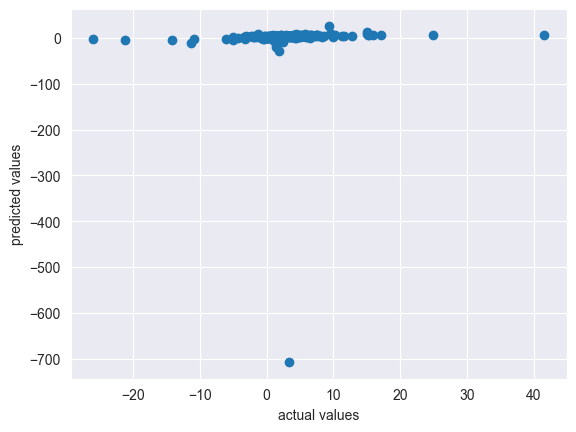

In [23]:
#scatter plot of actual values vs predicted values:
plt.scatter(y_test, predictions)
plt.xlabel('actual values')
plt.ylabel('predicted values')

<Axes: xlabel='Earnings Per Share', ylabel='Count'>

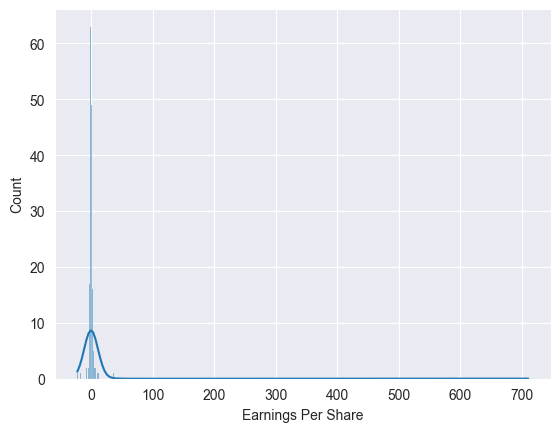

In [24]:
#histogram of residuals:
residuals = y_test - predictions
sns.histplot(residuals, kde = True)

In [25]:
#mae, rmse:
mae = metrics.mean_absolute_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
mae_percentage = (mae / y.mean()) * 100
rmse_percentage = (rmse / y.mean()) * 100
print(f'mae percentage = {mae_percentage}')
print(f'rmse percentage = {rmse_percentage}')

#very very bad ai model

mae percentage = 122.86461757299767
rmse percentage = 1091.6886790889275


# **Conclusion**

In [26]:
pd.DataFrame(data = model.coef_, index = x.columns, columns = ['Coefficient'])

,Coefficient
Unnamed: 0,-1.714563e-04
Accounts Payable,1.322412e-06
Accounts Receivable,2.908217e-10
Add'l income/expense items,-4.068382e-10
After Tax ROE,-2.139551e-03
...,...
Total Liabilities & Equity,3.053166e-09
Total Revenue,-3.024814e-09
Treasury Stock,1.015824e-10
For Year,4.011223e-03
